# Lens-pair dataset — random close Gaia/GOST scanning laws

This notebook creates synthetic **positive and negative lens-pair datasets**.

Core rule: for **every pair**, positive and negative, we draw a random sky position and a second close object. Then we query GOST for object A and object B separately. Positives and negatives therefore have the same sky/separation/scanning-law construction.

Outputs:
- `metadata.csv`
- `observations.csv`
- `continuous_curves.csv`
- for the small run: one plot per pair showing continuous curves, GOST-sampled points, and microlensing curves.


## 0. Optional install

In [1]:
# Uncomment if needed
# import sys
# !{sys.executable} -m pip install -U numpy pandas scipy matplotlib astropy requests amoeba-agn


## 1. Imports and configuration

In [ ]:
import json, time, hashlib, warnings
from pathlib import Path
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from scipy.ndimage import gaussian_filter1d
from astropy.time import Time
from astropy.io.votable import parse_single_table

warnings.filterwarnings("ignore", category=RuntimeWarning)

RUN_SMALL = True
RUN_BIG = False

USE_AMOEBA_IF_AVAILABLE = True
ALLOW_RED_NOISE_FALLBACK = True

OUTPUT_ROOT = Path("lens_pair_dataset_random_close_scanning")
GOST_CACHE_DIR = OUTPUT_ROOT / "gost_cache"
SMALL_DIR = OUTPUT_ROOT / "small"
BIG_DIR = OUTPUT_ROOT / "big"
for p in [OUTPUT_ROOT, GOST_CACHE_DIR, SMALL_DIR, BIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

GOST_SLEEP_BETWEEN_CALLS_SEC = 0.2
MAX_GOST_RETRIES_PER_OBJECT = 2
MAX_SKY_TRIES_PER_PAIR = 30

BASE_CONFIG = dict(
    n_days=2000,
    cadence_days=1.0,
    max_delay_days=400,
    gost_start_utc="2014-07-25T00:00:00",
    gost_end_utc="2025-01-15T00:00:00",
    maxrec=20000,
    min_dec_deg=-80.0,
    max_dec_deg=80.0,
    separation_arcsec_min=0.3,
    separation_arcsec_max=5.0,
    query_A_and_B_separately=True,
    band="r_620nm",
    fractional_variability=0.12,
    delay_min_days=5.0,
    delay_max_days=700.0,
    flux_ratio_min=0.2,
    flux_ratio_max=5.0,
    macro_mag_overall_min=0.8,
    macro_mag_overall_max=1.4,
    microlensing_strength_min=0.02,
    microlensing_strength_max=0.18,
    microlensing_smooth_days_min=80.0,
    microlensing_smooth_days_max=350.0,
    microlensing_clip_min=0.55,
    microlensing_clip_max=1.85,
    sigma_flux_frac_min=0.005,
    sigma_flux_frac_max=0.04,
    dropout_min=0.00,
    dropout_max=0.20,
    negative_types=["independent", "shifted_independent", "similar_confuser", "microlensing_confuser"],
)

CONFIG_SMALL = dict(**BASE_CONFIG, run_name="small", random_seed=123, n_positive=3, n_negative=3, output_dir=SMALL_DIR)
CONFIG_BIG = dict(**BASE_CONFIG, run_name="big", random_seed=456, n_positive=500, n_negative=500, output_dir=BIG_DIR)

print("Small output:", SMALL_DIR.resolve())
print("Big output:", BIG_DIR.resolve())


Small output: C:\Users\tpichard\Downloads\lens_pair_dataset_random_close_scanning\small
Big output: C:\Users\tpichard\Downloads\lens_pair_dataset_random_close_scanning\big


## 2. Random close-pair sky positions

Positive and negative pairs both use this function, so they share the same position and separation distributions.

In [3]:
def draw_random_sky_position(rng, min_dec_deg=-80.0, max_dec_deg=80.0):
    ra = rng.uniform(0.0, 360.0)
    s1 = np.sin(np.deg2rad(min_dec_deg))
    s2 = np.sin(np.deg2rad(max_dec_deg))
    dec = np.rad2deg(np.arcsin(rng.uniform(s1, s2)))
    return float(ra), float(dec)


def offset_radec_small_angle(ra_deg, dec_deg, separation_arcsec, position_angle_deg):
    sep_deg = separation_arcsec / 3600.0
    pa = np.deg2rad(position_angle_deg)
    cos_dec = max(np.cos(np.deg2rad(dec_deg)), 1e-6)
    ddec = sep_deg * np.cos(pa)
    dra = sep_deg * np.sin(pa) / cos_dec
    return float((ra_deg + dra) % 360.0), float(np.clip(dec_deg + ddec, -89.999, 89.999))


def draw_random_close_pair_position(config, rng):
    ra_A, dec_A = draw_random_sky_position(rng, config["min_dec_deg"], config["max_dec_deg"])
    sep_arcsec = rng.uniform(config["separation_arcsec_min"], config["separation_arcsec_max"])
    pa_deg = rng.uniform(0.0, 360.0)
    ra_B, dec_B = offset_radec_small_angle(ra_A, dec_A, sep_arcsec, pa_deg)
    return dict(
        ra_A=ra_A, dec_A=dec_A, ra_B=ra_B, dec_B=dec_B,
        separation_arcsec=float(sep_arcsec), position_angle_deg=float(pa_deg),
    )

rng_demo = np.random.default_rng(1)
for _ in range(3):
    print(draw_random_close_pair_position(CONFIG_SMALL, rng_demo))


{'ra_A': 184.2557848920924, 'dec_A': 62.52848451093142, 'ra_B': 184.255598249979, 'dec_B': 62.528742041111094, 'separation_arcsec': 0.9775501797822785, 'position_angle_deg': 341.5138009694078}
{'ra_A': 112.25932272377476, 'dec_A': -8.685891839441862, 'ra_B': 112.25995862709499, 'dec_B': -8.686871440018729, 'separation_arcsec': 4.190202190956076, 'position_angle_deg': 147.31168909289806}
{'ra_A': 197.85372756230143, 'dec_A': -68.51709795445447, 'ra_B': 197.8530359126077, 'dec_B': -68.51813454195083, 'separation_arcsec': 3.8415116107715908, 'position_angle_deg': 193.73159275894017}


## 3. GOST ObjVisSAP query + cache

This uses the corrected ObjVisSAP parameter names: `s_ra`, `s_dec`, `t_min`, `t_max`, `MAXREC`.

The notebook extracts the visit time from `t_start` / `t_stop` when these are present.

In [4]:
def utc_to_mjd(date_utc):
    return float(Time(pd.to_datetime(date_utc).to_pydatetime(), scale="utc").mjd)

def mjd_to_datetime(x):
    return pd.Series(Time(np.asarray(x, dtype=float), format="mjd", scale="utc").to_datetime())

def jd_to_datetime(x):
    return pd.Series(Time(np.asarray(x, dtype=float), format="jd", scale="utc").to_datetime())

def jyear_to_datetime(x):
    return pd.Series(Time(np.asarray(x, dtype=float), format="jyear", scale="utc").to_datetime())

def clean_object_columns(df):
    out = df.copy()
    for c in out.columns:
        if out[c].dtype == object:
            out[c] = out[c].map(lambda v: v.decode("utf-8", errors="replace") if isinstance(v, (bytes, bytearray)) else v)
    return out


def extract_gost_times(gost_df):
    cols = list(gost_df.columns)
    norm = {c: str(c).lower().replace(" ", "").replace("_", "").replace("-", "").replace("[", "").replace("]", "") for c in cols}

    start_cols = [c for c in cols if "tstart" in norm[c] or norm[c] in ["start", "starttime", "startmjd"]]
    stop_cols = [c for c in cols if "tstop" in norm[c] or norm[c] in ["stop", "stoptime", "stopmjd"]]
    if start_cols and stop_cols:
        t1 = pd.to_numeric(gost_df[start_cols[0]], errors="coerce")
        t2 = pd.to_numeric(gost_df[stop_cols[0]], errors="coerce")
        vals = (0.5 * (t1 + t2)).dropna().to_numpy()
        if len(vals) == 0:
            raise RuntimeError("GOST t_start/t_stop empty")
        med = np.nanmedian(vals)
        if med > 2_000_000:
            times = jd_to_datetime(vals)
        elif med > 40_000:
            times = mjd_to_datetime(vals)
        elif 1900 < med < 2200:
            times = jyear_to_datetime(vals)
        else:
            raise RuntimeError(f"Unknown GOST time scale; median={med}")
        return times.dropna().drop_duplicates().sort_values().reset_index(drop=True)

    for c in cols:
        name = norm[c]
        if ("date" in name or "utc" in name or "eventdate" in name or "observationtimeatgaia" in name) and not pd.api.types.is_numeric_dtype(gost_df[c]):
            times = pd.to_datetime(gost_df[c].astype(str).str.replace("(TCB)", "", regex=False).str.replace("(UTC)", "", regex=False).str.strip(), errors="coerce")
            times = pd.Series(times).dropna().drop_duplicates().sort_values().reset_index(drop=True)
            if len(times) > 0:
                return times

    for c in cols:
        if not pd.api.types.is_numeric_dtype(gost_df[c]):
            continue
        name = norm[c]
        if not ("mjd" in name or "jd" in name or "time" in name or "epoch" in name):
            continue
        vals = pd.to_numeric(gost_df[c], errors="coerce").dropna().to_numpy()
        if len(vals) == 0:
            continue
        med = np.nanmedian(vals)
        if med > 2_000_000:
            times = jd_to_datetime(vals)
        elif med > 40_000:
            times = mjd_to_datetime(vals)
        elif 1900 < med < 2200:
            times = jyear_to_datetime(vals)
        else:
            continue
        return times.dropna().drop_duplicates().sort_values().reset_index(drop=True)

    raise RuntimeError(f"Could not identify GOST time column. Columns: {cols}")


def gost_cache_path(ra_deg, dec_deg, start_utc, end_utc, maxrec):
    key = f"ra={ra_deg:.7f}|dec={dec_deg:.7f}|start={start_utc}|end={end_utc}|maxrec={maxrec}"
    digest = hashlib.sha1(key.encode("utf-8")).hexdigest()[:16]
    return GOST_CACHE_DIR / f"gost_{digest}.csv"


def query_gost_objvissap_raw(ra_deg, dec_deg, start_utc, end_utc, maxrec=20000, timeout=180):
    url = "https://gaia.esac.esa.int/gost/ObjVisSAP/gaiaobjvisap"
    params = dict(
        s_ra=float(ra_deg),
        s_dec=float(dec_deg),
        t_min=utc_to_mjd(start_utc),
        t_max=utc_to_mjd(end_utc),
        MAXREC=int(maxrec),
    )
    headers = {"User-Agent": "python-gost-random-close-pair-dataset", "Accept": "application/x-votable+xml;charset=utf-8;serialization=TABLE"}
    r = requests.get(url, params=params, headers=headers, timeout=timeout)
    raw = r.content
    if r.status_code != 200:
        raise RuntimeError(f"GOST HTTP {r.status_code}: {r.url}\n{raw[:1000].decode('utf-8', errors='replace')}")
    preview = raw[:1000].decode("utf-8", errors="replace").lower()
    if "<html" in preview or "<!doctype html" in preview:
        raise RuntimeError(f"GOST returned HTML instead of VOTable: {r.url}")
    table = parse_single_table(BytesIO(raw)).to_table()
    return clean_object_columns(table.to_pandas()), r.url


def get_gost_times_cached(ra_deg, dec_deg, config):
    path = gost_cache_path(ra_deg, dec_deg, config["gost_start_utc"], config["gost_end_utc"], config["maxrec"])
    if path.exists():
        return pd.Series(pd.to_datetime(pd.read_csv(path)["gost_time"])).dropna().drop_duplicates().sort_values().reset_index(drop=True)

    last_error = None
    for attempt in range(MAX_GOST_RETRIES_PER_OBJECT):
        try:
            gost_df, used_url = query_gost_objvissap_raw(ra_deg, dec_deg, config["gost_start_utc"], config["gost_end_utc"], config["maxrec"])
            times = extract_gost_times(gost_df)
            start_dt = pd.to_datetime(config["gost_start_utc"])
            end_dt = pd.to_datetime(config["gost_end_utc"])
            times = times[(times >= start_dt) & (times <= end_dt)].reset_index(drop=True)
            if len(times) == 0:
                raise RuntimeError("GOST returned zero times in local window")
            pd.DataFrame({"gost_time": times}).to_csv(path, index=False)
            time.sleep(GOST_SLEEP_BETWEEN_CALLS_SEC)
            return times
        except Exception as e:
            last_error = e
            time.sleep(1.0 + attempt)
    raise RuntimeError(f"GOST failed for RA={ra_deg}, Dec={dec_deg}: {last_error}")


def times_to_simulation_days(times, start_utc):
    t0 = pd.to_datetime(start_utc)
    return (pd.Series(pd.to_datetime(times)) - t0).dt.total_seconds().to_numpy() / 86400.0


## 4. Intrinsic AGN generator: Amoeba if available, red-noise fallback if not

In [5]:
def red_noise_flux(t_days, seed, frac_var=0.12, alpha=2.0):
    rng = np.random.default_rng(seed)
    t_days = np.asarray(t_days, dtype=float)
    n = len(t_days)
    dt = np.median(np.diff(t_days)) if n > 1 else 1.0
    freq = np.fft.rfftfreq(n, d=dt)
    amp = np.zeros_like(freq)
    m = freq > 0
    amp[m] = freq[m] ** (-alpha / 2.0)
    phase = rng.uniform(0, 2 * np.pi, size=len(freq))
    coeff = amp * (np.cos(phase) + 1j * np.sin(phase))
    x = np.fft.irfft(coeff, n=n)
    if not np.isfinite(np.std(x)) or np.std(x) == 0:
        x = rng.normal(size=n)
    x = (x - np.mean(x)) / np.std(x)
    return np.clip(1.0 + frac_var * x, 0.05, None)


class IntrinsicAGNGenerator:
    def __init__(self, config):
        self.config = config
        self.mode = "red_noise"
        self.disk = None
        self.smbh_mass_exp = 8.5
        self.redshift_source = 0.5
        self.band_wavelength_nm = 620.0
        if not USE_AMOEBA_IF_AVAILABLE:
            print("Intrinsic generator: red-noise")
            return
        try:
            from amoeba.Util.util import create_maps
            from amoeba.Classes.accretion_disk import AccretionDisk
            disk_kwargs = create_maps(
                smbh_mass_exp=self.smbh_mass_exp,
                redshift_source=self.redshift_source,
                number_grav_radii=800,
                inclination_angle=30,
                resolution=350,
                eddington_ratio=0.1,
                spin=0.0,
                temp_beta=1.0,
                generic_beta=True,
            )
            self.disk = AccretionDisk(**disk_kwargs)
            self.mode = "amoeba"
            print("Intrinsic generator: Amoeba")
        except Exception as e:
            if not ALLOW_RED_NOISE_FALLBACK:
                raise
            print("Intrinsic generator: red-noise fallback")
            print("Amoeba unavailable or failed:", repr(e))

    def generate(self, t_days, seed):
        t_days = np.asarray(t_days, dtype=float)
        n = len(t_days)
        if self.mode == "amoeba":
            try:
                from amoeba.Util.util import generate_signal_from_psd, convolve_signal_with_transfer_function
                freq = np.linspace(1 / (2 * max(n, 2)), 1 / 2, n)
                psd = freq ** (-2.0)
                _, driving = generate_signal_from_psd(n, psd, freq, int(seed))
                driving = np.asarray(driving)
                driving = (driving - np.mean(driving)) / np.std(driving)
                tf = self.disk.construct_accretion_disk_transfer_function(self.band_wavelength_nm)
                _, lc = convolve_signal_with_transfer_function(
                    smbh_mass_exp=self.smbh_mass_exp,
                    driving_signal=driving,
                    transfer_function=tf,
                    initial_time_axis=np.arange(n, dtype=float),
                    redshift_source=self.redshift_source,
                    desired_cadence_in_days=self.config["cadence_days"],
                )
                lc = np.asarray(lc)[:n]
                lc = (lc - np.mean(lc)) / np.std(lc)
                return np.clip(1.0 + self.config["fractional_variability"] * lc, 0.05, None)
            except Exception as e:
                if not ALLOW_RED_NOISE_FALLBACK:
                    raise
                print("Amoeba generation failed; using fallback:", repr(e))
        return red_noise_flux(t_days, seed, self.config["fractional_variability"])


## 5. Microlensing and sampling utilities

In [6]:
def generate_smooth_microlensing(t_days, seed, strength=0.1, smooth_days=200.0, clip_min=0.55, clip_max=1.85):
    rng = np.random.default_rng(seed)
    t_days = np.asarray(t_days, dtype=float)
    n = len(t_days)
    dt = np.median(np.diff(t_days)) if n > 1 else 1.0
    sigma_samples = max(1.0, smooth_days / dt)
    trend = gaussian_filter1d(rng.normal(size=n), sigma=sigma_samples, mode="reflect")
    for _ in range(rng.integers(1, 4)):
        center = rng.uniform(t_days.min(), t_days.max())
        width = rng.uniform(0.15, 0.45) * (t_days.max() - t_days.min())
        trend += rng.normal() * np.exp(-0.5 * ((t_days - center) / width) ** 2)
    trend = trend - np.mean(trend)
    if not np.isfinite(np.std(trend)) or np.std(trend) == 0:
        trend = rng.normal(size=n)
    trend = trend / np.std(trend)
    mu = 1.0 + strength * trend
    mu = gaussian_filter1d(mu, sigma=max(1.0, 0.15 * sigma_samples), mode="reflect")
    mu = np.clip(mu, clip_min, clip_max)
    return mu / np.mean(mu)


def interp_curve(tq, t, y):
    return np.interp(tq, t, y, left=np.nan, right=np.nan)


def robust_noise_sigma(values, sigma_frac):
    scale = np.nanmedian(np.abs(values))
    if not np.isfinite(scale) or scale <= 0:
        scale = np.nanstd(values)
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    return float(sigma_frac * scale)


def sample_one_image(pair_id, image_id, t_cont, flux_cont, gost_times, config, rng, sigma_frac, dropout_frac):
    sim_days = times_to_simulation_days(gost_times, config["gost_start_utc"])
    mask = (sim_days >= t_cont.min()) & (sim_days <= t_cont.max())
    sim_days = sim_days[mask]
    gost_times_used = pd.Series(pd.to_datetime(gost_times))[mask].reset_index(drop=True)
    if len(sim_days) == 0:
        return pd.DataFrame()
    true = interp_curve(sim_days, t_cont, flux_cont)
    ok = np.isfinite(true)
    sim_days, true = sim_days[ok], true[ok]
    gost_times_used = gost_times_used[ok].reset_index(drop=True)
    keep = rng.random(len(true)) >= dropout_frac
    sim_days, true = sim_days[keep], true[keep]
    gost_times_used = gost_times_used[keep].reset_index(drop=True)
    if len(true) == 0:
        return pd.DataFrame()
    sigma = robust_noise_sigma(true, sigma_frac)
    obs = true + rng.normal(0.0, sigma, size=len(true))
    return pd.DataFrame(dict(pair_id=pair_id, image_id=image_id, gost_time=gost_times_used, time_days=sim_days, flux_true=true, flux_obs=obs, flux_err=np.full(len(true), sigma)))


def make_continuous_dataframe(pair_id, label, t, flux_A, flux_B, mu_A, mu_B, src_A, src_B):
    return pd.concat([
        pd.DataFrame(dict(pair_id=pair_id, label_lensed=label, image_id="A", time_days=t, intrinsic_component=src_A, microlensing_mu=mu_A, flux_continuous=flux_A)),
        pd.DataFrame(dict(pair_id=pair_id, label_lensed=label, image_id="B", time_days=t, intrinsic_component=src_B, microlensing_mu=mu_B, flux_continuous=flux_B)),
    ], ignore_index=True)


## 6. Pair generation

For positives, both images share the same intrinsic source with a true delay.

For negatives, A and B are different intrinsic sources, but they still use close sky positions and GOST scanning laws just like positives.

In [7]:
def get_pair_gost_times(sky, config):
    times_A = get_gost_times_cached(sky["ra_A"], sky["dec_A"], config)
    if config.get("query_A_and_B_separately", True):
        times_B = get_gost_times_cached(sky["ra_B"], sky["dec_B"], config)
    else:
        times_B = times_A.copy()
    return times_A, times_B


def common_microlensing_and_noise(config, rng, t_cont, negative_type=None):
    if negative_type == "microlensing_confuser":
        strength_A = rng.uniform(0.12, 0.30)
        strength_B = rng.uniform(0.12, 0.30)
    else:
        strength_A = rng.uniform(config["microlensing_strength_min"], config["microlensing_strength_max"])
        strength_B = rng.uniform(config["microlensing_strength_min"], config["microlensing_strength_max"])
    smooth_A = rng.uniform(config["microlensing_smooth_days_min"], config["microlensing_smooth_days_max"])
    smooth_B = rng.uniform(config["microlensing_smooth_days_min"], config["microlensing_smooth_days_max"])
    mu_A = generate_smooth_microlensing(t_cont, int(rng.integers(1, 2_000_000_000)), strength_A, smooth_A, config["microlensing_clip_min"], config["microlensing_clip_max"])
    mu_B = generate_smooth_microlensing(t_cont, int(rng.integers(1, 2_000_000_000)), strength_B, smooth_B, config["microlensing_clip_min"], config["microlensing_clip_max"])
    sigma_A = rng.uniform(config["sigma_flux_frac_min"], config["sigma_flux_frac_max"])
    sigma_B = rng.uniform(config["sigma_flux_frac_min"], config["sigma_flux_frac_max"])
    dropout_A = rng.uniform(config["dropout_min"], config["dropout_max"])
    dropout_B = rng.uniform(config["dropout_min"], config["dropout_max"])
    return mu_A, mu_B, strength_A, strength_B, smooth_A, smooth_B, sigma_A, sigma_B, dropout_A, dropout_B


def generate_positive_pair(pair_index, config, rng, gen):
    pair_id = f"pos_{pair_index:06d}"
    sky = draw_random_close_pair_position(config, rng)
    times_A, times_B = get_pair_gost_times(sky, config)
    t_cont = np.arange(0.0, config["n_days"] + config["cadence_days"], config["cadence_days"])
    delay = rng.uniform(config["delay_min_days"], config["delay_max_days"])
    pad = config["max_delay_days"] + 30.0
    t_src = np.arange(-pad, config["n_days"] + config["cadence_days"], config["cadence_days"])
    source_seed = int(rng.integers(1, 2_000_000_000))
    source = gen.generate(t_src, source_seed)
    src_A = interp_curve(t_cont, t_src, source)
    src_B = interp_curve(t_cont - delay, t_src, source)
    ratio = 10 ** rng.uniform(np.log10(config["flux_ratio_min"]), np.log10(config["flux_ratio_max"]))
    macro_A = rng.uniform(config["macro_mag_overall_min"], config["macro_mag_overall_max"])
    macro_B = macro_A / ratio
    mu_A, mu_B, sA, sB, smA, smB, sigA, sigB, dropA, dropB = common_microlensing_and_noise(config, rng, t_cont)
    flux_A = macro_A * src_A * mu_A
    flux_B = macro_B * src_B * mu_B
    obs_A = sample_one_image(pair_id, "A", t_cont, flux_A, times_A, config, rng, sigA, dropA)
    obs_B = sample_one_image(pair_id, "B", t_cont, flux_B, times_B, config, rng, sigB, dropB)
    if len(obs_A) < 5 or len(obs_B) < 5:
        raise RuntimeError("Too few sampled points")
    obs = pd.concat([obs_A, obs_B], ignore_index=True)
    obs["label_lensed"] = 1
    obs["band"] = config["band"]
    cont = make_continuous_dataframe(pair_id, 1, t_cont, flux_A, flux_B, mu_A, mu_B, src_A, src_B)
    meta = dict(pair_id=pair_id, label_lensed=1, negative_type="none", source_seed_A=source_seed, source_seed_B=source_seed, true_delay_days=float(delay), confuser_shift_days=np.nan, flux_ratio_A_over_B=float(ratio), macro_mag_A=float(macro_A), macro_mag_B=float(macro_B), microlensing_strength_A=float(sA), microlensing_strength_B=float(sB), microlensing_smooth_days_A=float(smA), microlensing_smooth_days_B=float(smB), sigma_flux_frac_A=float(sigA), sigma_flux_frac_B=float(sigB), dropout_A=float(dropA), dropout_B=float(dropB), n_obs_A=int(len(obs_A)), n_obs_B=int(len(obs_B)), **sky)
    return meta, obs, cont


def generate_negative_pair(pair_index, config, rng, gen):
    pair_id = f"neg_{pair_index:06d}"
    sky = draw_random_close_pair_position(config, rng)
    times_A, times_B = get_pair_gost_times(sky, config)
    t_cont = np.arange(0.0, config["n_days"] + config["cadence_days"], config["cadence_days"])
    pad = config["max_delay_days"] + 30.0
    t_src = np.arange(-pad, config["n_days"] + config["cadence_days"], config["cadence_days"])
    negative_type = str(rng.choice(config["negative_types"]))
    seed_A = int(rng.integers(1, 2_000_000_000))
    seed_B = int(rng.integers(1, 2_000_000_000))
    source_A = gen.generate(t_src, seed_A)
    source_B = gen.generate(t_src, seed_B)
    fake_shift = 0.0
    if negative_type in ["shifted_independent", "similar_confuser"]:
        fake_shift = rng.uniform(config["delay_min_days"], config["delay_max_days"])
    src_A = interp_curve(t_cont, t_src, source_A)
    src_B = interp_curve(t_cont - fake_shift, t_src, source_B)
    macro_A = rng.uniform(config["macro_mag_overall_min"], config["macro_mag_overall_max"])
    macro_B = rng.uniform(config["macro_mag_overall_min"], config["macro_mag_overall_max"])
    ratio = macro_A / macro_B
    mu_A, mu_B, sA, sB, smA, smB, sigA, sigB, dropA, dropB = common_microlensing_and_noise(config, rng, t_cont, negative_type=negative_type)
    flux_A = macro_A * src_A * mu_A
    flux_B = macro_B * src_B * mu_B
    obs_A = sample_one_image(pair_id, "A", t_cont, flux_A, times_A, config, rng, sigA, dropA)
    obs_B = sample_one_image(pair_id, "B", t_cont, flux_B, times_B, config, rng, sigB, dropB)
    if len(obs_A) < 5 or len(obs_B) < 5:
        raise RuntimeError("Too few sampled points")
    obs = pd.concat([obs_A, obs_B], ignore_index=True)
    obs["label_lensed"] = 0
    obs["band"] = config["band"]
    cont = make_continuous_dataframe(pair_id, 0, t_cont, flux_A, flux_B, mu_A, mu_B, src_A, src_B)
    meta = dict(pair_id=pair_id, label_lensed=0, negative_type=negative_type, source_seed_A=seed_A, source_seed_B=seed_B, true_delay_days=np.nan, confuser_shift_days=float(fake_shift), flux_ratio_A_over_B=float(ratio), macro_mag_A=float(macro_A), macro_mag_B=float(macro_B), microlensing_strength_A=float(sA), microlensing_strength_B=float(sB), microlensing_smooth_days_A=float(smA), microlensing_smooth_days_B=float(smB), sigma_flux_frac_A=float(sigA), sigma_flux_frac_B=float(sigB), dropout_A=float(dropA), dropout_B=float(dropB), n_obs_A=int(len(obs_A)), n_obs_B=int(len(obs_B)), **sky)
    return meta, obs, cont


## 7. Dataset builder

In [8]:
def build_dataset(config):
    outdir = Path(config["output_dir"])
    outdir.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(config["random_seed"])
    gen = IntrinsicAGNGenerator(config)
    metas, obs_parts, cont_parts = [], [], []

    def build_class(label, n_target):
        generated, attempts = 0, 0
        while generated < n_target:
            attempts += 1
            if attempts > n_target * MAX_SKY_TRIES_PER_PAIR:
                raise RuntimeError(f"Too many failures for label={label}")
            try:
                if label == 1:
                    meta, obs, cont = generate_positive_pair(generated, config, rng, gen)
                else:
                    meta, obs, cont = generate_negative_pair(generated, config, rng, gen)
                metas.append(meta)
                obs_parts.append(obs)
                cont_parts.append(cont)
                generated += 1
                print(f"[{config['run_name']}] label={label} {generated}/{n_target}: {meta['pair_id']} sep={meta['separation_arcsec']:.2f} arcsec")
            except Exception as e:
                print(f"[{config['run_name']}] retry label={label}; reason: {e}")

    build_class(1, config["n_positive"])
    build_class(0, config["n_negative"])

    metadata = pd.DataFrame(metas)
    observations = pd.concat(obs_parts, ignore_index=True)
    continuous = pd.concat(cont_parts, ignore_index=True)

    metadata.to_csv(outdir / "metadata.csv", index=False)
    observations.to_csv(outdir / "observations.csv", index=False)
    continuous.to_csv(outdir / "continuous_curves.csv", index=False)
    with open(outdir / "config.json", "w", encoding="utf-8") as f:
        json.dump({k: str(v) if isinstance(v, Path) else v for k, v in config.items()}, f, indent=2)

    print("Saved to", outdir.resolve())
    return metadata, observations, continuous


## 8. Plots: every small pair + microlensing

In [9]:
def plot_pair(pair_id, metadata, observations, continuous, save_dir=None):
    meta = metadata.loc[metadata["pair_id"] == pair_id].iloc[0]
    obs = observations[observations["pair_id"] == pair_id]
    cont = continuous[continuous["pair_id"] == pair_id]
    label = int(meta["label_lensed"])
    label_txt = "positive lensed" if label == 1 else f"negative: {meta['negative_type']}"

    fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
    for image_id, marker in [("A", "o"), ("B", "s")]:
        c = cont[cont["image_id"] == image_id]
        o = obs[obs["image_id"] == image_id]
        axes[0].plot(c["time_days"], c["flux_continuous"], lw=1.8, label=f"image {image_id} continuous")
        axes[0].errorbar(o["time_days"], o["flux_obs"], yerr=o["flux_err"], fmt=marker, ms=4, capsize=2, alpha=0.85, label=f"image {image_id} GOST sampled")
        axes[1].plot(c["time_days"], c["microlensing_mu"], lw=2.0, label=f"mu {image_id}")
        axes[2].plot(c["time_days"], c["intrinsic_component"], lw=1.5, label=f"intrinsic component {image_id}")

    axes[0].set_title(f"{pair_id} — {label_txt}\nsep={meta['separation_arcsec']:.2f} arcsec | A=({meta['ra_A']:.4f},{meta['dec_A']:.4f}) B=({meta['ra_B']:.4f},{meta['dec_B']:.4f})")
    axes[0].set_ylabel("Flux")
    axes[0].legend()
    axes[1].axhline(1.0, ls="--", lw=1)
    axes[1].set_ylabel("Microlensing mu")
    axes[1].legend()
    axes[2].set_ylabel("Intrinsic component")
    axes[2].set_xlabel("Time from GOST start [days]")
    axes[2].legend()
    if label == 1:
        txt = f"true delay={meta['true_delay_days']:.1f} d | flux ratio A/B={meta['flux_ratio_A_over_B']:.2f}"
    else:
        txt = f"fake/confuser shift={meta['confuser_shift_days']:.1f} d"
    axes[0].text(0.01, 0.03, txt, transform=axes[0].transAxes)
    plt.tight_layout()
    if save_dir is not None:
        Path(save_dir).mkdir(parents=True, exist_ok=True)
        fig.savefig(Path(save_dir) / f"{pair_id}.png", dpi=160, bbox_inches="tight")
    plt.show()


def plot_all_small_pairs(metadata, observations, continuous, output_dir):
    plot_dir = Path(output_dir) / "pair_plots"
    for pair_id in metadata["pair_id"]:
        plot_pair(pair_id, metadata, observations, continuous, save_dir=plot_dir)
    print("Saved pair plots in", plot_dir.resolve())


def plot_dataset_qc(metadata, observations, title="Dataset QC"):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()
    metadata["label_lensed"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
    axes[0].set_title("Labels")
    axes[1].hist(metadata["separation_arcsec"], bins=20)
    axes[1].set_title("Separation [arcsec]")
    axes[2].hist(metadata["dec_A"], bins=20)
    axes[2].set_title("Dec distribution")
    pos = metadata[metadata["label_lensed"] == 1]
    if len(pos):
        axes[3].hist(pos["true_delay_days"].dropna(), bins=20)
    axes[3].set_title("True delays, positives")
    axes[4].hist(metadata["n_obs_A"], bins=20, alpha=0.7, label="A")
    axes[4].hist(metadata["n_obs_B"], bins=20, alpha=0.7, label="B")
    axes[4].set_title("N observations")
    axes[4].legend()
    dts = []
    for _, g in observations.sort_values("time_days").groupby(["pair_id", "image_id"]):
        dts.extend(np.diff(g["time_days"].to_numpy()))
    if len(dts):
        axes[5].hist(dts, bins=40)
    axes[5].set_title("GOST cadence")
    axes[5].set_xlabel("days")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


## 9. Run small implementation

Intrinsic generator: Amoeba
[small] label=1 1/3: pos_000000 sep=1.34 arcsec
[small] label=1 2/3: pos_000001 sep=3.55 arcsec
[small] label=1 3/3: pos_000002 sep=4.61 arcsec
[small] label=0 1/3: neg_000000 sep=1.25 arcsec
[small] label=0 2/3: neg_000001 sep=1.50 arcsec
[small] label=0 3/3: neg_000002 sep=3.41 arcsec
Saved to C:\Users\tpichard\Downloads\lens_pair_dataset_random_close_scanning\small


,pair_id,label_lensed,negative_type,source_seed_A,source_seed_B,true_delay_days,confuser_shift_days,flux_ratio_A_over_B,macro_mag_A,macro_mag_B,...,dropout_A,dropout_B,n_obs_A,n_obs_B,ra_A,dec_A,ra_B,dec_B,separation_arcsec,position_angle_deg
0,pos_000000,1,none,695605074,695605074,127.254601,NaN,3.906708,0.965945,0.247253,...,0.125988,0.185481,101,88,245.646671,-61.498070,245.647383,-61.497921,1.335691,66.373852
1,pos_000001,1,none,1648483192,1648483192,367.826897,NaN,1.967305,0.816079,0.414821,...,0.128024,0.170626,75,65,105.841600,-10.551092,105.842070,-10.551962,3.547746,152.032770
2,pos_000002,1,none,1036252404,1036252404,303.212476,NaN,2.525781,1.007509,0.398890,...,0.155419,0.173258,84,90,180.974857,44.684013,180.975788,44.685108,4.605067,31.165217
3,neg_000000,0,independent,1417565089,866192655,NaN,0.000000,1.363622,1.163224,0.853040,...,0.022646,0.076963,95,89,204.032104,-36.212065,204.032157,-36.211721,1.247645,7.113378
4,neg_000001,0,similar_confuser,1636020331,283351001,NaN,82.062495,0.736859,0.813620,1.104173,...,0.121506,0.041996,205,231,307.313458,28.140363,307.313468,28.139946,1.501836,178.749633
5,neg_000002,0,similar_confuser,410209424,334502830,NaN,430.100497,1.213985,1.047244,0.862649,...,0.198332,0.056268,67,80,310.896125,-5.534817,310.895203,-5.534581,3.410317,284.460183


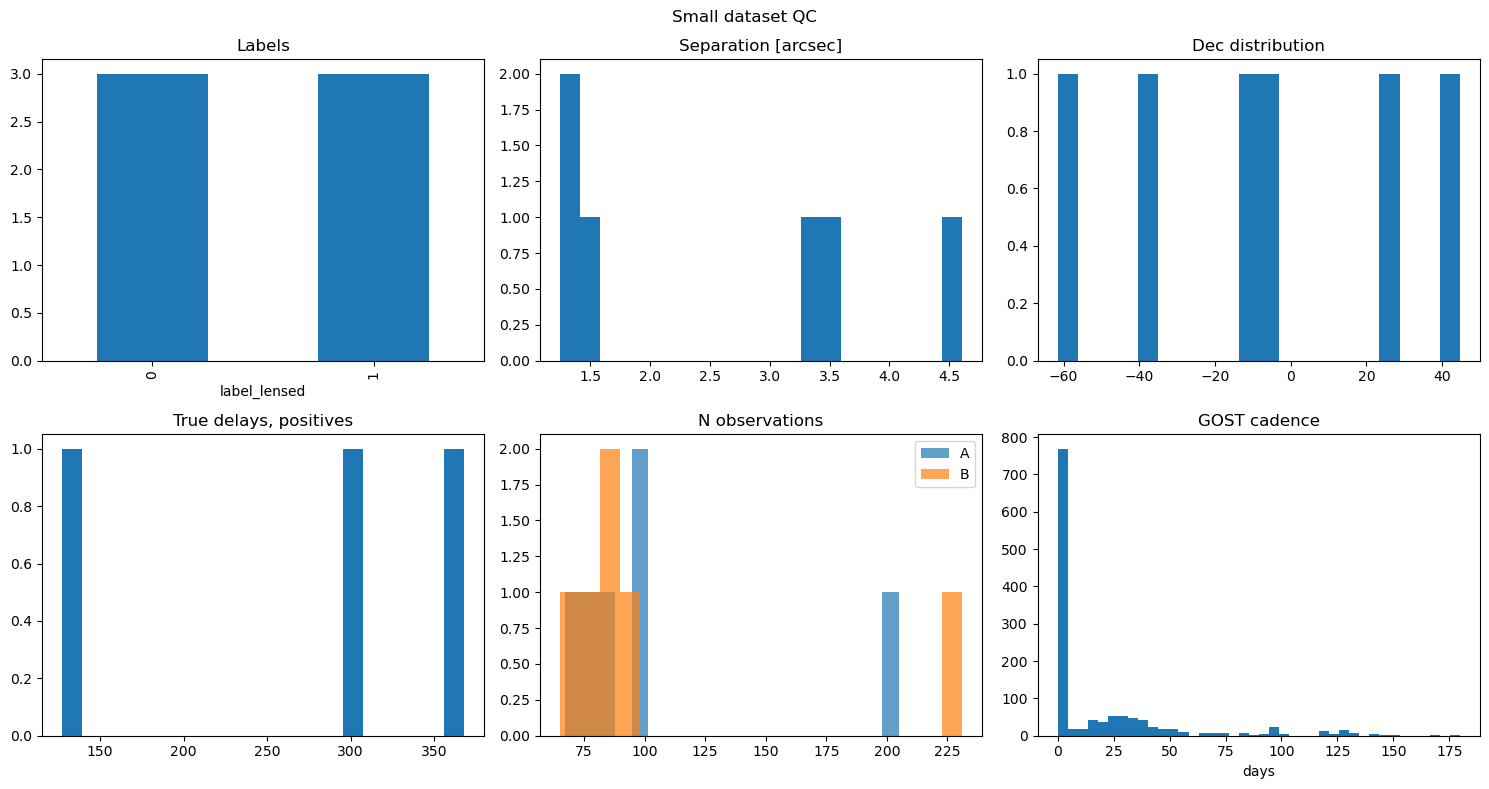

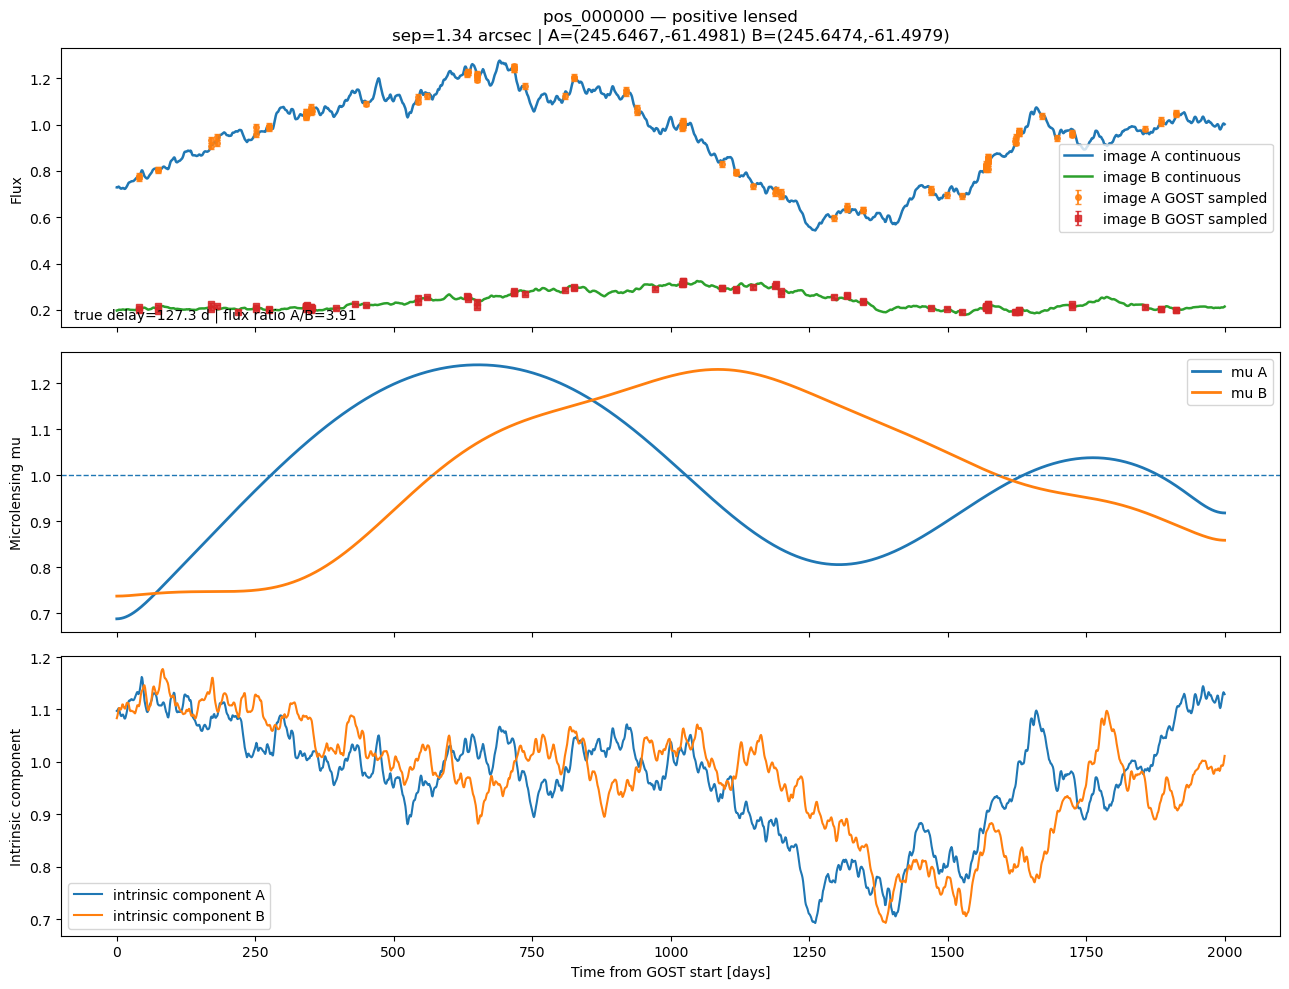

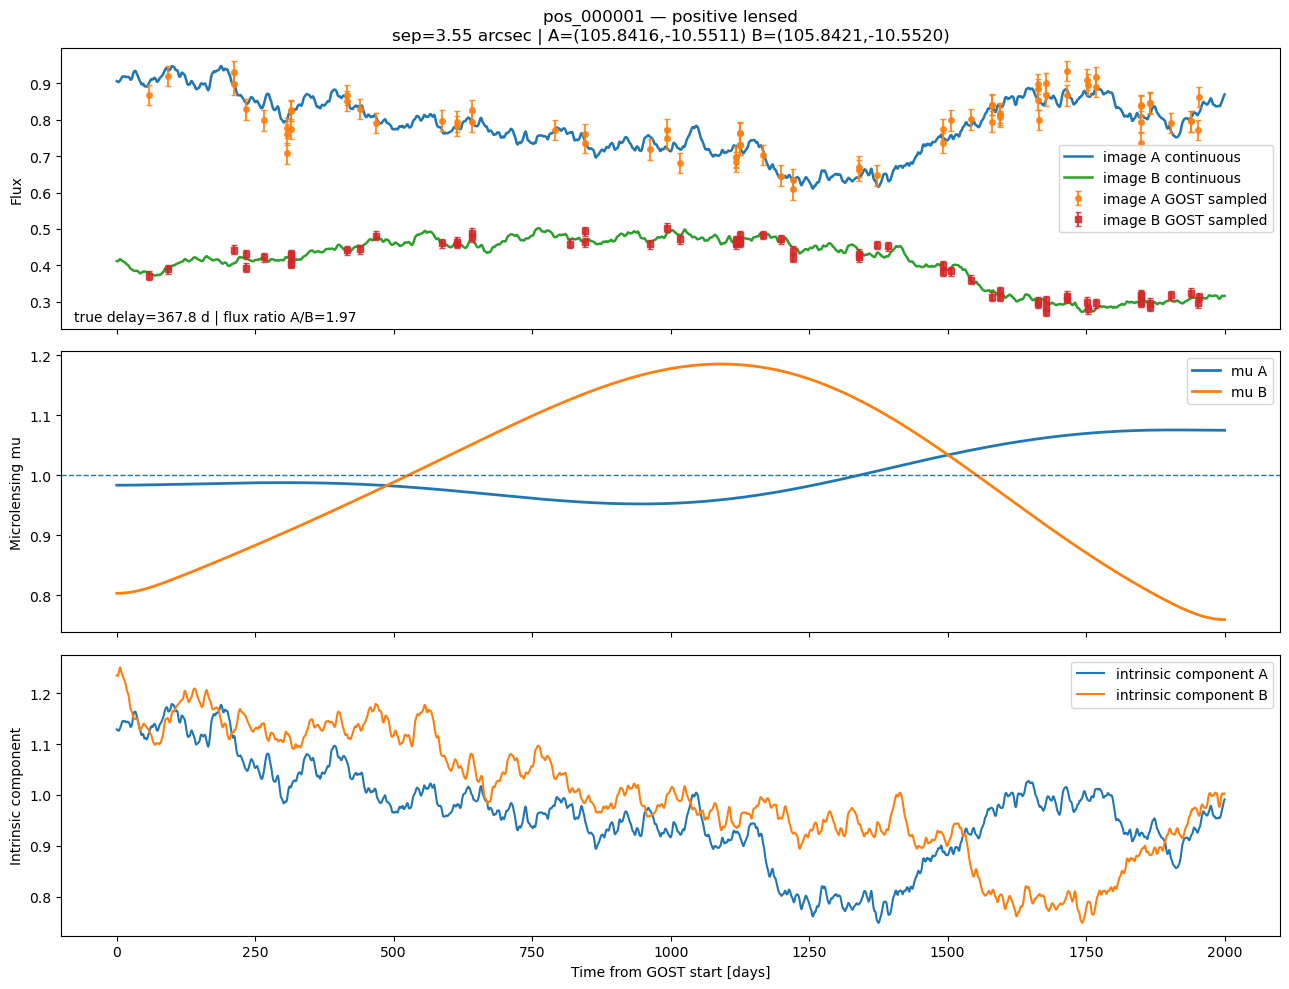

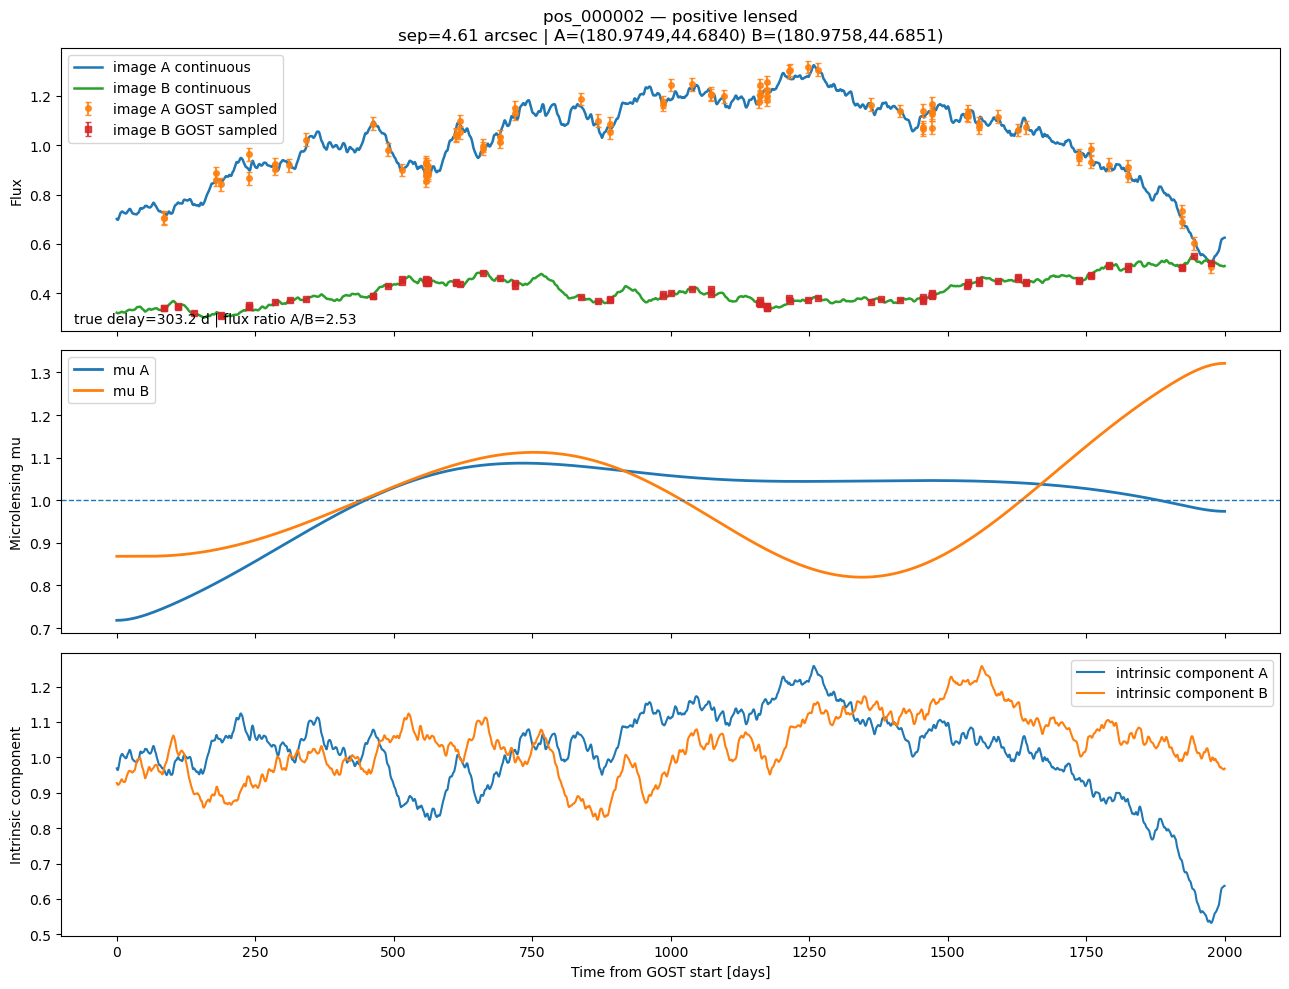

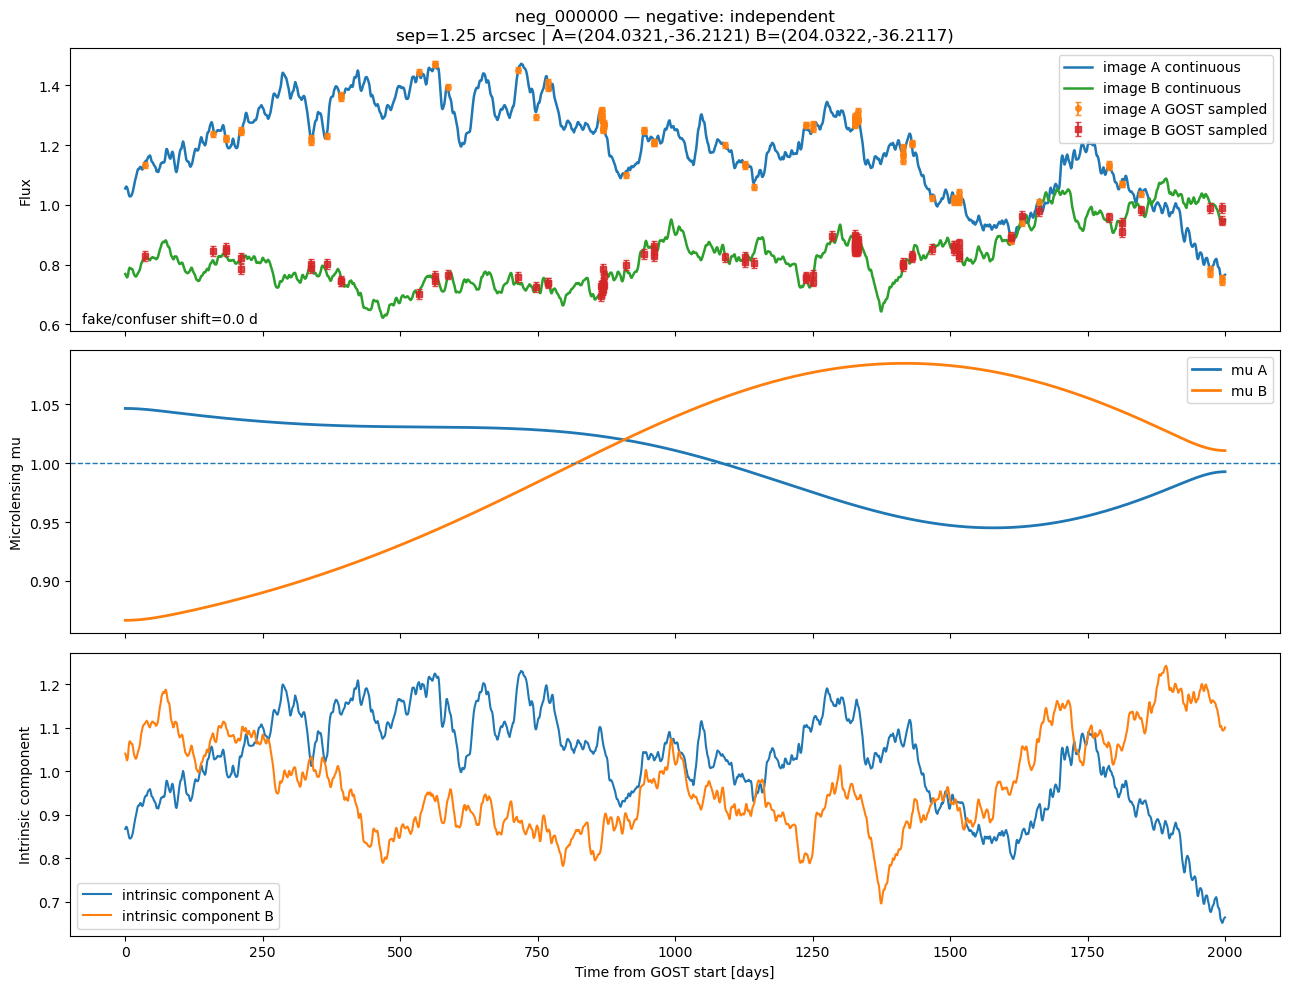

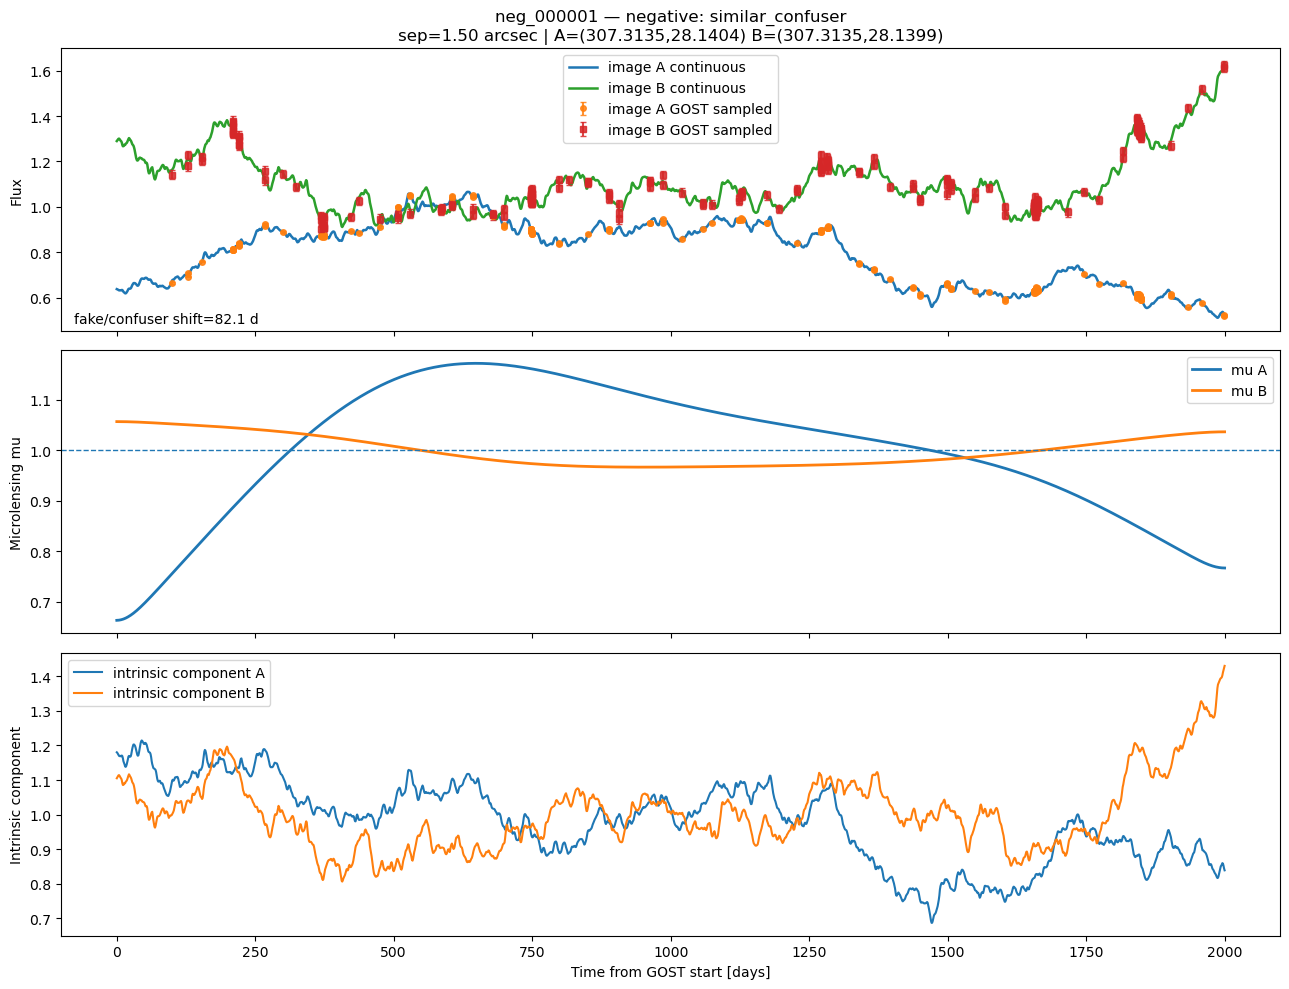

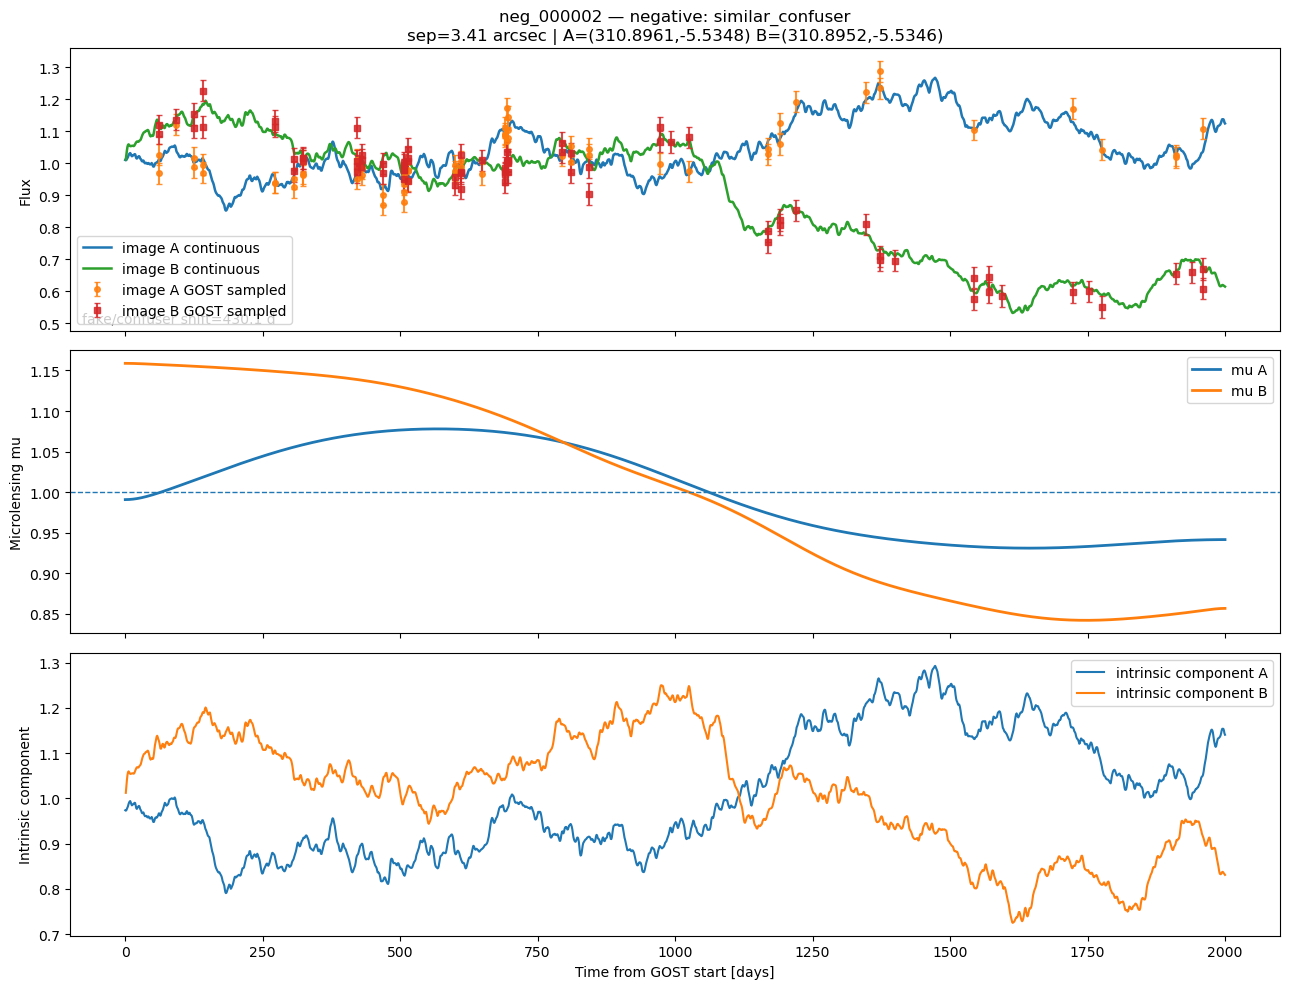

Saved pair plots in C:\Users\tpichard\Downloads\lens_pair_dataset_random_close_scanning\small\pair_plots


In [10]:
if RUN_SMALL:
    small_metadata, small_observations, small_continuous = build_dataset(CONFIG_SMALL)
    display(small_metadata)
    plot_dataset_qc(small_metadata, small_observations, title="Small dataset QC")
    plot_all_small_pairs(small_metadata, small_observations, small_continuous, CONFIG_SMALL["output_dir"])
else:
    print("RUN_SMALL=False")


## 10. Run big implementation

Set `RUN_BIG=True` in the config cell when the small run looks correct. The big run will query many random close sky pairs, so it can take time.

Intrinsic generator: Amoeba
[big] label=1 1/500: pos_000000 sep=0.88 arcsec
[big] label=1 2/500: pos_000001 sep=2.02 arcsec
[big] label=1 3/500: pos_000002 sep=3.72 arcsec
[big] label=1 4/500: pos_000003 sep=3.95 arcsec
[big] label=1 5/500: pos_000004 sep=2.35 arcsec
[big] label=1 6/500: pos_000005 sep=3.06 arcsec
[big] label=1 7/500: pos_000006 sep=1.88 arcsec
[big] label=1 8/500: pos_000007 sep=4.24 arcsec
[big] label=1 9/500: pos_000008 sep=2.14 arcsec
[big] label=1 10/500: pos_000009 sep=0.83 arcsec
[big] label=1 11/500: pos_000010 sep=4.56 arcsec
[big] label=1 12/500: pos_000011 sep=4.86 arcsec
[big] label=1 13/500: pos_000012 sep=0.81 arcsec
[big] label=1 14/500: pos_000013 sep=4.29 arcsec
[big] label=1 15/500: pos_000014 sep=0.85 arcsec
[big] label=1 16/500: pos_000015 sep=2.51 arcsec
[big] label=1 17/500: pos_000016 sep=1.58 arcsec
[big] label=1 18/500: pos_000017 sep=4.04 arcsec
[big] label=1 19/500: pos_000018 sep=0.41 arcsec
[big] label=1 20/500: pos_000019 sep=2.06 arcsec
[

,pair_id,label_lensed,negative_type,source_seed_A,source_seed_B,true_delay_days,confuser_shift_days,flux_ratio_A_over_B,macro_mag_A,macro_mag_B,...,dropout_A,dropout_B,n_obs_A,n_obs_B,ra_A,dec_A,ra_B,dec_B,separation_arcsec,position_angle_deg
0,pos_000000,1,none,132123114,132123114,681.226976,NaN,0.532641,1.277632,2.398673,...,0.109499,0.067658,77,64,169.082368,-5.917649,169.082121,-5.917642,0.883067,271.745993
1,pos_000001,1,none,1053087659,1053087659,301.348546,NaN,1.849680,0.834374,0.451091,...,0.035790,0.000637,81,82,172.831912,27.602638,172.831630,27.603140,2.019370,333.500737
2,pos_000002,1,none,676481692,676481692,446.091045,NaN,1.590057,1.202280,0.756124,...,0.166155,0.128497,70,81,168.101604,30.050177,168.100531,30.049726,3.716627,244.096748
3,pos_000003,1,none,477953057,477953057,557.622839,NaN,0.317800,0.977074,3.074497,...,0.017656,0.180334,71,51,114.281809,47.028702,114.280209,47.028828,3.952101,276.604899
4,pos_000004,1,none,1244033531,1244033531,176.558864,NaN,4.305334,1.363892,0.316791,...,0.043413,0.140993,50,46,65.970546,37.970687,65.971125,37.971152,2.345936,44.452556


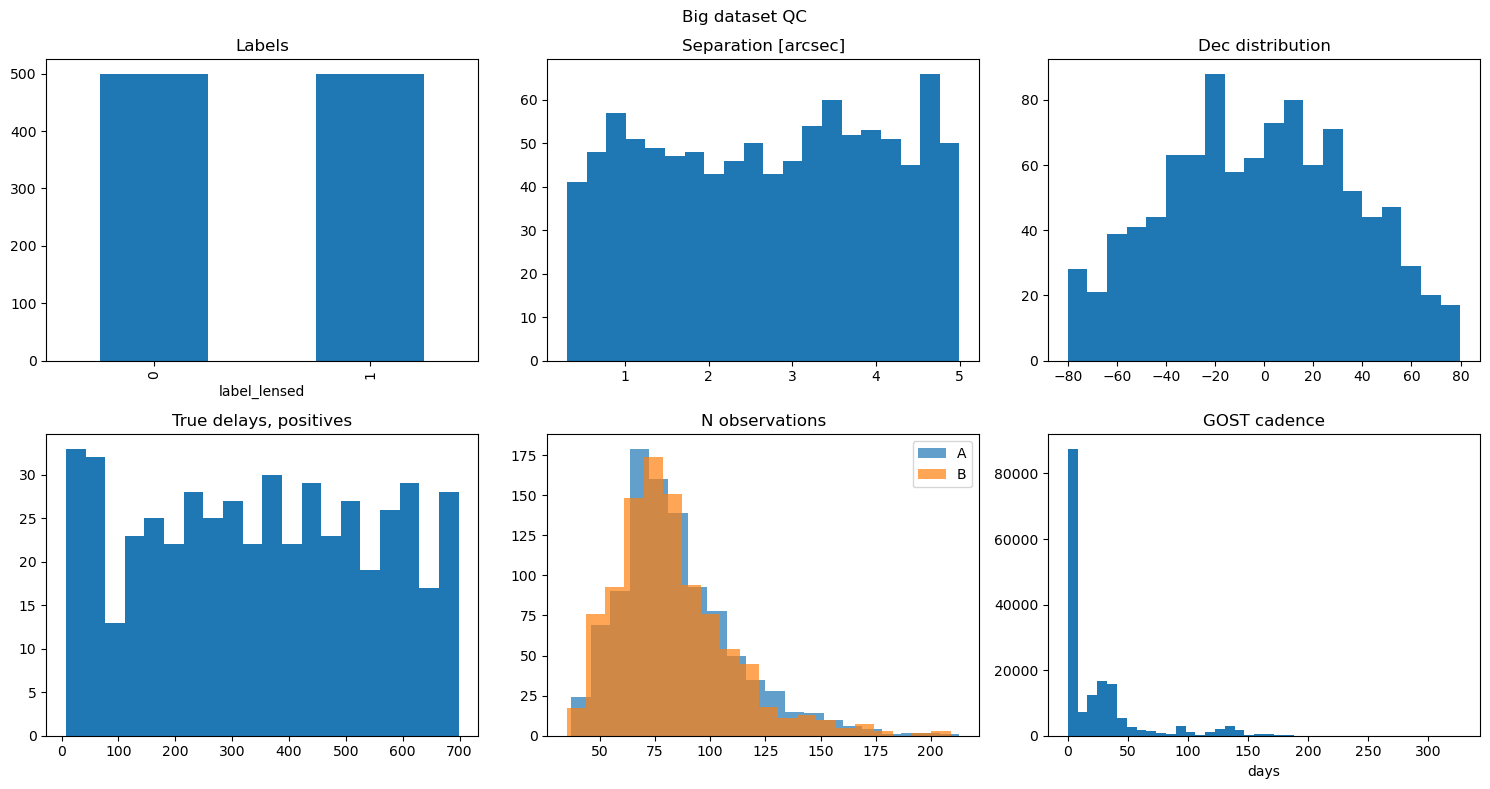

In [11]:
if RUN_BIG:
    big_metadata, big_observations, big_continuous = build_dataset(CONFIG_BIG)
    display(big_metadata.head())
    plot_dataset_qc(big_metadata, big_observations, title="Big dataset QC")
else:
    print("RUN_BIG=False. Set RUN_BIG=True in the first config cell when ready.")
